In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision.utils import make_grid
from sdelib import (
    GaussianConditionalProbabilityPath,
    LinearConditionalProbabilityPath,
    UNet,
    CFGTrainer,
    LinearAlpha,
    LinearBeta,
    IsotropicGaussian,
    CFGVectorFieldODE,
    EulerSimulator
)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [2]:
class MNISTSampler(nn.Module):
    def __init__(self, root='./lab03/data'):
        super().__init__()
        transform = Compose([Resize(32), ToTensor(), 
                            lambda x: (x - 0.5) * 2])  # Normalize to [-1, 1]
        self.dataset = MNIST(root, train=True, download=True, 
                            transform=transform)
    
    def sample(self, num_samples):
        indices = torch.randint(0, len(self.dataset), (num_samples,))
        images = torch.stack([self.dataset[i][0] for i in indices])
        labels = torch.tensor([self.dataset[i][1] for i in indices])
        return images, labels

In [3]:
path = GaussianConditionalProbabilityPath(
    p_data=MNISTSampler(root='./lab03/data'),
    p_simple=IsotropicGaussian([1, 32, 32]),  # For 32x32 grayscale
    alpha=LinearAlpha(),
    beta=LinearBeta()
).to(device)

unet = UNet(
    in_channels=1,
    out_channels=1,
    channels=[32, 64, 128],
    num_residual_layers=2,
    t_embed_dim=40,
    y_embed_dim=40,
    num_classes=11  # 10 classes + 1 null label
).to(device)

trainer = CFGTrainer(
    path=path,
    model=unet,
    eta=0.1,  # 10% label dropout rate
    device=device)

losses = trainer.train(num_epochs=100, lr=1e-3, batch_size=256)

Training model with size: 4.715 MiB


Epoch 99, loss: 697.0003: 100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


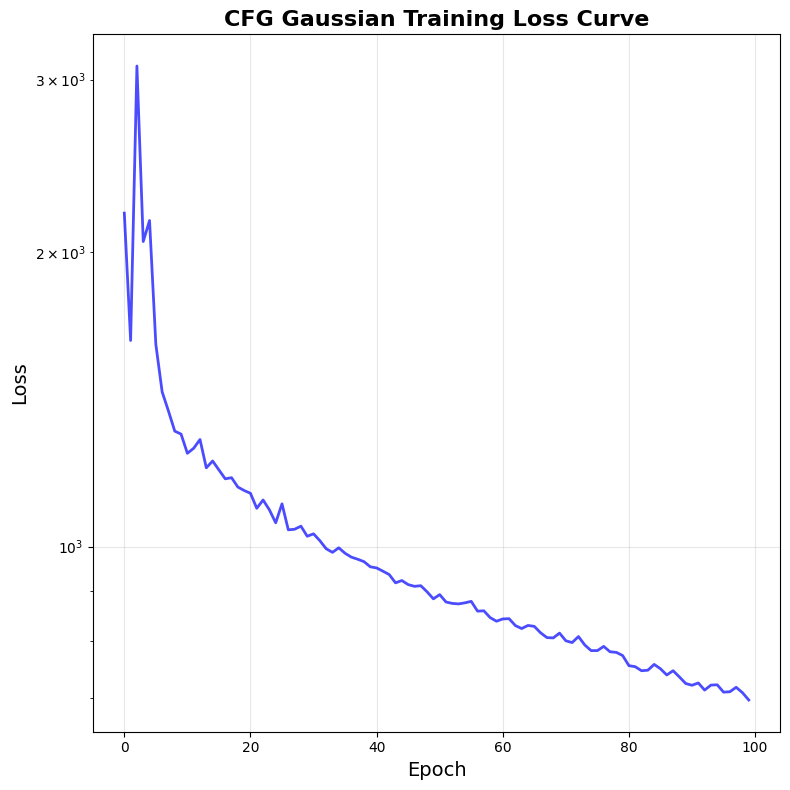

Initial loss: 2191.2825
Final loss: 697.0003
Loss reduction: 68.19%


In [4]:
plt.figure(figsize=(8, 8))
plt.plot(losses, linewidth=2, color='blue', alpha=0.7)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('CFG Gaussian Training Loss Curve', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.2f}%")

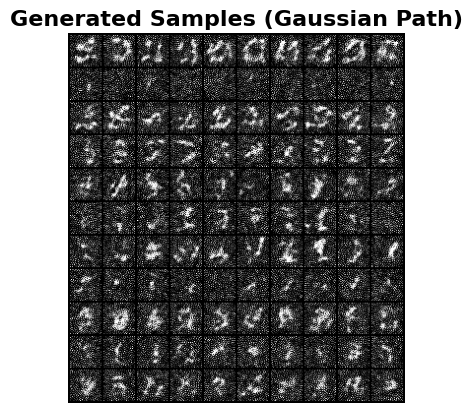

In [5]:
ode = CFGVectorFieldODE(unet, guidance_scale=3.0)
simulator = EulerSimulator(ode)
y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(10).to(device)
x0, _ = path.p_simple.sample(y.shape[0])
ts = torch.linspace(0, 1, 100).view(1, -1, 1, 1, 1).expand(y.shape[0], -1, 1, 1, 1).to(device)
x1 = simulator.simulate(x0, ts, y=y)
grid = make_grid(x1, nrow=10, normalize=True, value_range=(-1, 1))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated Samples (Gaussian Path)", fontsize=16, fontweight='bold')
plt.show()

In [9]:
path = LinearConditionalProbabilityPath(
    p_data=MNISTSampler(root='./lab03/data'),
    p_simple=IsotropicGaussian([1, 32, 32]),  # For 32x32 grayscale
).to(device)

unet = UNet(
    in_channels=1,
    out_channels=1,
    channels=[32, 64, 128],
    num_residual_layers=2,
    t_embed_dim=40,
    y_embed_dim=40,
    num_classes=11  # 10 classes + 1 null label
).to(device)

trainer = CFGTrainer(
    path=path,
    model=unet,
    eta=0.1,  # 10% label dropout rate
    device=device
)

losses = trainer.train(num_epochs=100, lr=1e-3, batch_size=256)

Training model with size: 4.715 MiB


Epoch 99, loss: 699.9760: 100%|██████████| 100/100 [00:34<00:00,  2.86it/s]


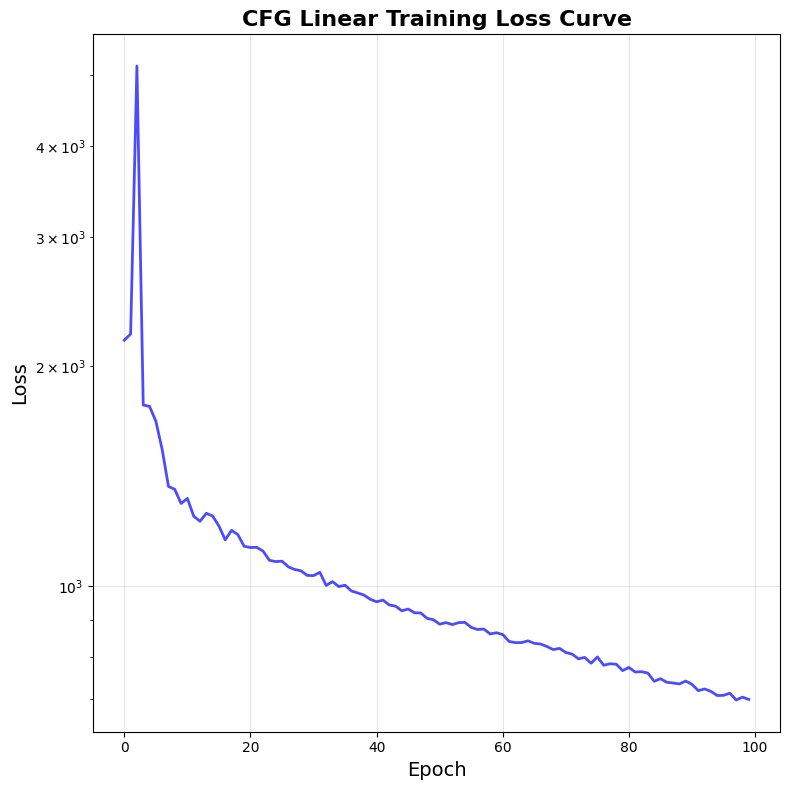

Initial loss: 2170.2485
Final loss: 699.9760
Loss reduction: 67.75%


In [10]:
plt.figure(figsize=(8, 8))
plt.plot(losses, linewidth=2, color='blue', alpha=0.7)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('CFG Linear Training Loss Curve', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log') 
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.2f}%")

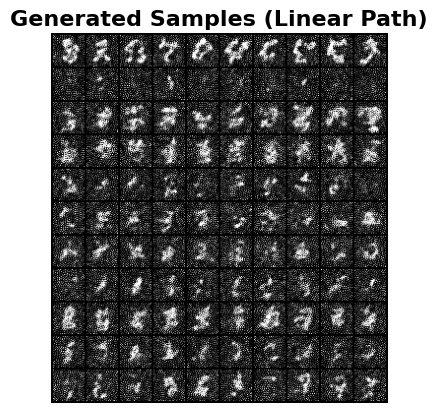

In [25]:
ode = CFGVectorFieldODE(unet, guidance_scale=3.0)
simulator = EulerSimulator(ode)
y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(10).to(device)
x0, _ = path.p_simple.sample(y.shape[0])
ts = torch.linspace(0, 1, 100).view(1, -1, 1, 1, 1).expand(y.shape[0], -1, 1, 1, 1).to(device)
x1 = simulator.simulate(x0, ts, y=y)
grid = make_grid(x1, nrow=10, normalize=True, value_range=(-1, 1))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated Samples (Linear Path)", fontsize=16, fontweight='bold')
plt.show()